### Assignment 5

In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np

print("t_daily_min:", type(t_daily_min), np.shape(t_daily_min))
print("t_daily_max:", type(t_daily_max), np.shape(t_daily_max))
print("p_daily_calc:", type(p_daily_calc), np.shape(p_daily_calc))
print("soil_moisture_5:", type(soil_moisture_5), np.shape(soil_moisture_5))
print("date:", type(date), np.shape(date))

t_daily_min: <class 'numpy.ndarray'> (1096,)
t_daily_max: <class 'numpy.ndarray'> (1096,)
p_daily_calc: <class 'numpy.ndarray'> (1096,)
soil_moisture_5: <class 'numpy.ndarray'> (1096,)
date: <class 'numpy.ndarray'> (1096,)


In [3]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


In [4]:
import matplotlib.pyplot as plt

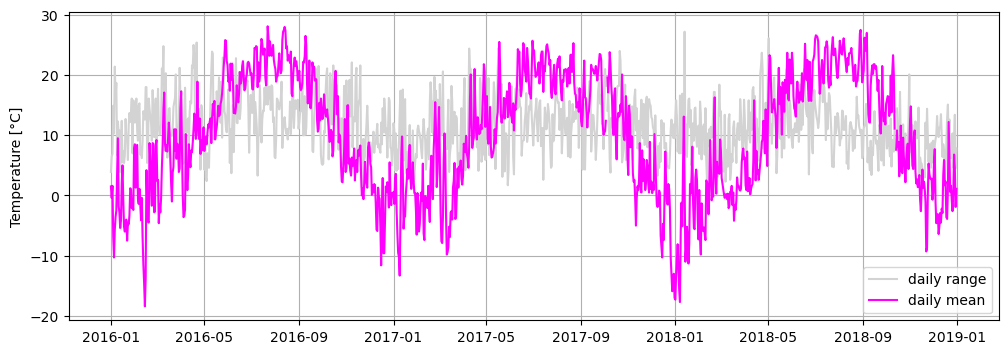

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# daily range = max - min
t_range = t_daily_max - t_daily_min

# plot
plt.figure(figsize=(12,4))

# background grey
plt.plot(date, t_range, color="lightgray", label="daily range")

# purple daily mean
plt.plot(date, t_daily_mean, color="magenta", label="daily mean")

plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True)
plt.show()

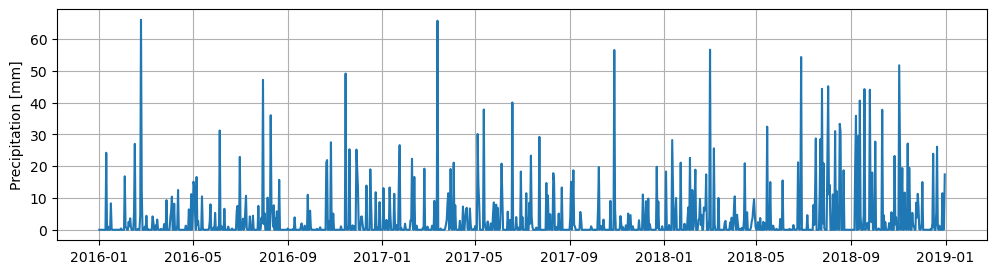

In [6]:
plt.figure(figsize=(12,3))
plt.plot(date, p_daily_calc)
plt.ylabel("Precipitation [mm]")
plt.grid(True)
plt.show()

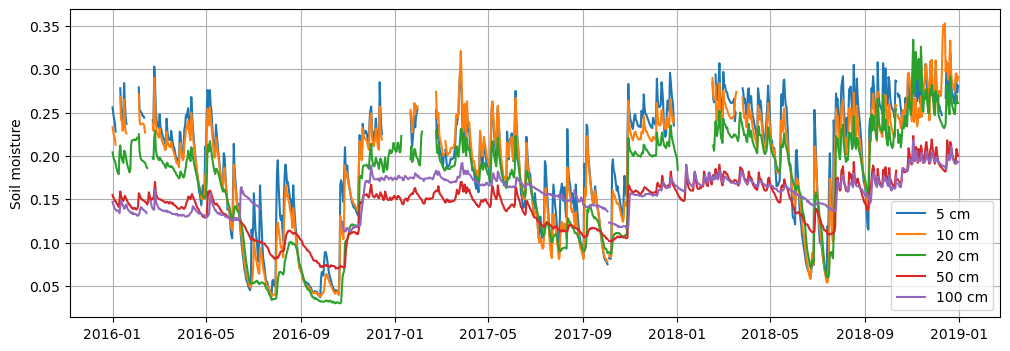

In [7]:
plt.figure(figsize=(12,4))

plt.plot(date, soil_moisture_5, label="5 cm")
plt.plot(date, soil_moisture_10, label="10 cm")
plt.plot(date, soil_moisture_20, label="20 cm")
plt.plot(date, soil_moisture_50, label="50 cm")
plt.plot(date, soil_moisture_100, label="100 cm")

plt.ylabel("Soil moisture")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


In [11]:
print("temp:", temp.shape)
print("lon:", lon.shape)
print("lat:", lat.shape)

temp: (94, 192)
lon: (192,)
lat: (94,)


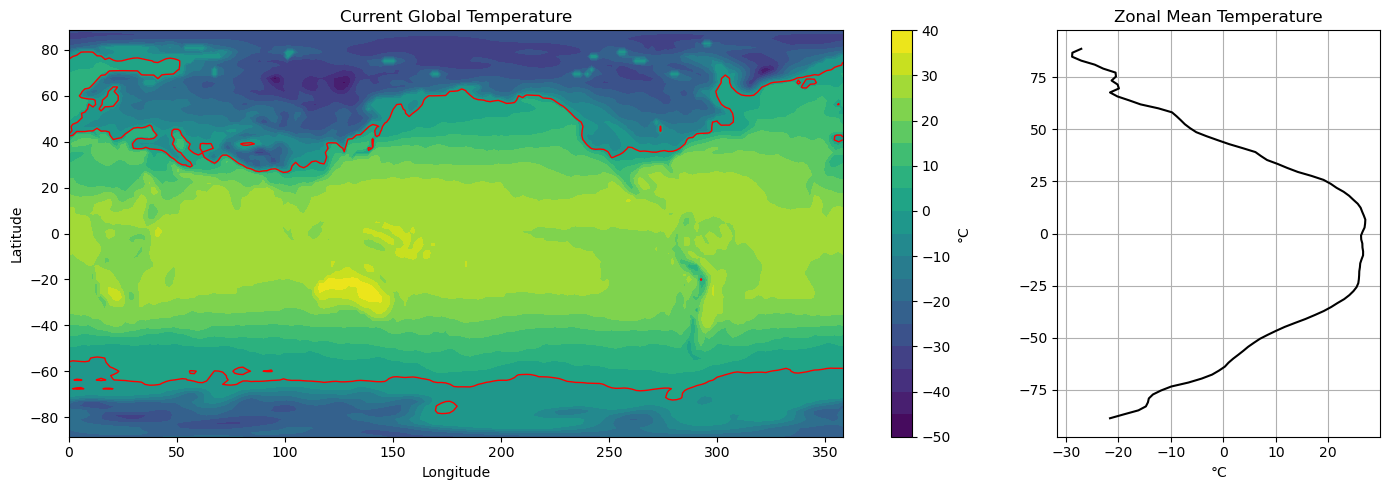

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Zonal mean = mean over longitude 
zonal_mean = np.mean(temp, axis=1)

# 2) Two-panel layout 
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

# Left panel: filled contours of temperature
cf = ax1.contourf(lon, lat, temp, levels=20)
ax1.set_title("Current Global Temperature")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# Red contour line (0°C)
ax1.contour(lon, lat, temp, levels=[0], colors="red", linewidths=1)

# Colorbar
fig.colorbar(cf, ax=ax1, label="°C")

# zonal mean (temperature vs latitude)
ax2.plot(zonal_mean, lat, color="black")
ax2.set_title("Zonal Mean Temperature")
ax2.set_xlabel("°C")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/fc2831/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/fc2831/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


/tmp/ipykernel_501132/1883960280.py:1: RuntimeWarning: divide by zero encountered in log10
  c = np.log10(depth)


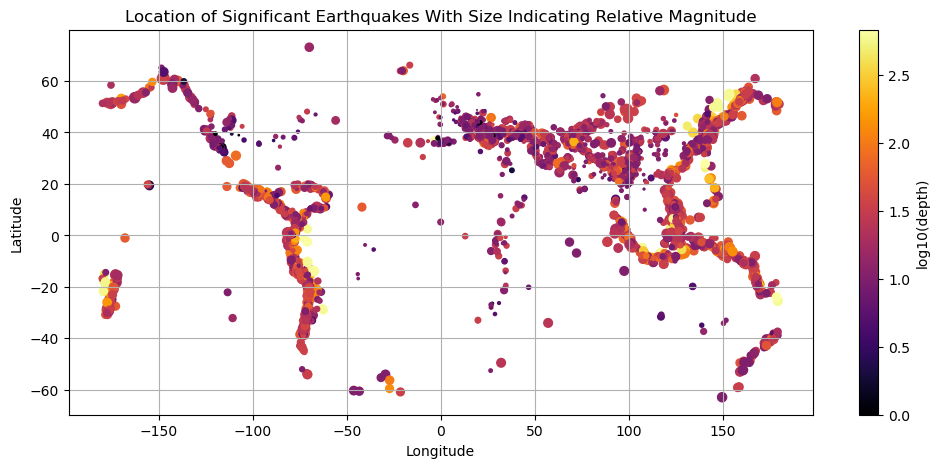

In [17]:
c = np.log10(depth)
s = (magnitude**4) / 100

plt.figure(figsize=(12,5))
sc = plt.scatter(longitude, latitude, c=c, s=s, cmap="inferno")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location of Significant Earthquakes With Size Indicating Relative Magnitude")
plt.grid(True)
plt.colorbar(sc, label="log10(depth)")
plt.show()